In [3]:
# %pip install pmdarima

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error

df = pd.read_csv("../data/monthly.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df[df['Date'] >= '1971-01-01'].copy().reset_index(drop=True)

test_size = 24
train = df.iloc[:-test_size].copy()
test = df.iloc[-test_size:].copy()

print(f"Train: {len(train)} months")
print(f"Test: {len(test)} months")

Train: 638 months
Test: 24 months


In [4]:
print("Fitting Auto ARIMA... ")

arima_model = auto_arima(
    train['Price'],
    start_p=1, start_q=1,
    max_p=5, max_q=5,
    d=1,
    seasonal=False,
    stepwise=True,
    suppress_warnings=True,
    information_criterion='aic',
    error_action='ignore'
)

print(arima_model.summary())

Fitting Auto ARIMA... 
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  638
Model:               SARIMAX(1, 1, 2)   Log Likelihood               -3096.039
Date:                Wed, 15 Apr 2026   AIC                           6202.078
Time:                        13:01:47   BIC                           6224.362
Sample:                             0   HQIC                          6210.729
                                - 638                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      5.6109      2.834      1.980      0.048       0.057      11.165
ar.L1         -0.8059      0.091     -8.870      0.000      -0.984      -0.628
ma.L1          1.0301      0.

In [5]:
# ARIMA predictions 
arima_pred = arima_model.predict(n_periods=test_size)

mae_arima = mean_absolute_error(test['Price'], arima_pred)
print(f"ARIMA(1,1,2) MAE: {mae_arima:.2f}")
print(f"Baseline (Naive) MAE: 1129.51")
print(f"Improvement over Naive: {((1129.51 - mae_arima) / 1129.51 * 100):.1f}%")

ARIMA(1,1,2) MAE: 1096.23
Baseline (Naive) MAE: 1129.51
Improvement over Naive: 2.9%


In [6]:
# Exponential Smoothing
es_model = ExponentialSmoothing(
    train['Price'],
    trend='add',
    seasonal=None,
    damped_trend=True
)

es_fit = es_model.fit(optimized=True)
es_pred = es_fit.forecast(test_size)

mae_es = mean_absolute_error(test['Price'], es_pred)
print(f"Exponential Smoothing MAE: {mae_es:.2f}")
print(f"Baseline (Naive) MAE: 1129.51")
print(f"ARIMA MAE: 1096.23")

Exponential Smoothing MAE: 1115.83
Baseline (Naive) MAE: 1129.51
ARIMA MAE: 1096.23


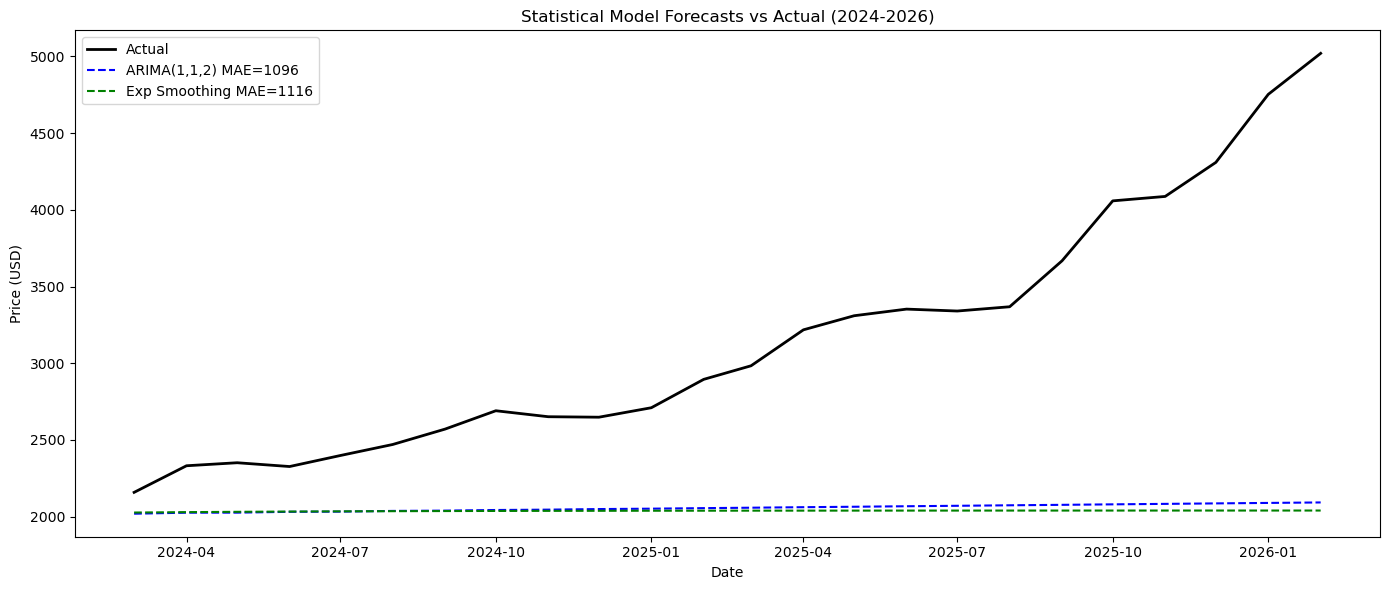

In [7]:
# Plotting predictions vs actual
plt.figure(figsize=(14, 6))
plt.plot(test['Date'], test['Price'], label='Actual', color='black', linewidth=2)
plt.plot(test['Date'], arima_pred, label=f'ARIMA(1,1,2) MAE={mae_arima:.0f}', linestyle='--', color='blue')
plt.plot(test['Date'], es_pred.values, label=f'Exp Smoothing MAE={mae_es:.0f}', linestyle='--', color='green')
plt.title('Statistical Model Forecasts vs Actual (2024-2026)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()